
# Chapter 11: Graphical examples with SVMs using different kernels


### Importing the necessary packages

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

### Plotting functions

In [3]:
def plot_points(features, labels):
    X = np.array(features)
    y = np.array(labels)
    spam = X[np.argwhere(y==1)]
    ham = X[np.argwhere(y==0)]
    plt.scatter([s[0][0] for s in spam],
                   [s[0][1] for s in spam],
                   s = 35,
                   color = 'cyan',
                   edgecolor = 'k',
                   marker = '^')
    plt.scatter([s[0][0] for s in ham],
                   [s[0][1] for s in ham],
                   s = 25,
                   color = 'red',
                   edgecolor = 'k',
                   marker = 's')
    plt.xlabel('x_1')
    plt.ylabel('x_2')
    plt.legend(['label 1','label 0'])

def plot_model(X, y, model):
    X = np.array(X)
    y = np.array(y)
    plot_step = 0.01
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contour(xx, yy, Z,colors = 'k',linewidths = 3)
    plot_points(X, y)
    plt.contourf(xx, yy, Z, colors=['red', 'blue'], alpha=0.2, levels=range(-1,2))
    plt.show()

### Loading dataset

In [5]:
# Loading the linear dataset

linear_data = pd.read_csv('linear.csv')
features = np.array(linear_data[['x_1', 'x_2']])
labels = np.array(linear_data['y'])

### Defining and plotting our dataset

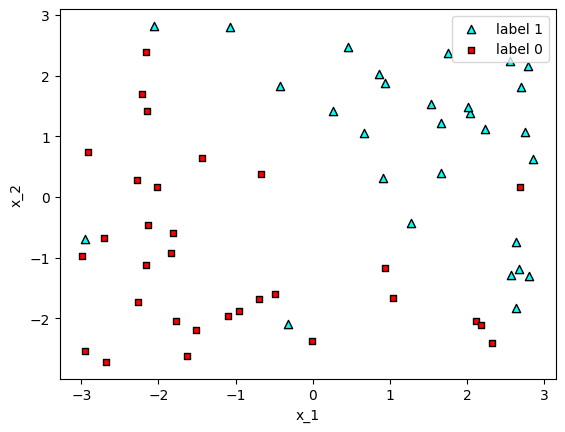

In [6]:
plot_points(features, labels)

In [7]:
features[:10]

array([[ 0.91320877,  0.31029938],
       [ 1.66135093,  1.22662676],
       [-1.6337402 , -2.62602954],
       [-2.70191727, -0.66960002],
       [-0.95474826, -1.8811995 ],
       [ 0.46133926,  2.47523667],
       [-2.16633895,  2.39458005],
       [-2.95360532, -2.53959343],
       [ 2.67868068, -1.18035578],
       [-0.00669429, -2.37322249]])

In [8]:
labels[:10]

array([1, 1, 0, 0, 0, 1, 0, 0, 1, 0])

### Training our SVM model

In [9]:
svm_linear = SVC(kernel='linear')
svm_linear.fit(features, labels)

SVC(kernel='linear')

In [10]:
print("Accuracy:", svm_linear.score(features, labels))

Accuracy: 0.95


### Plotting the results


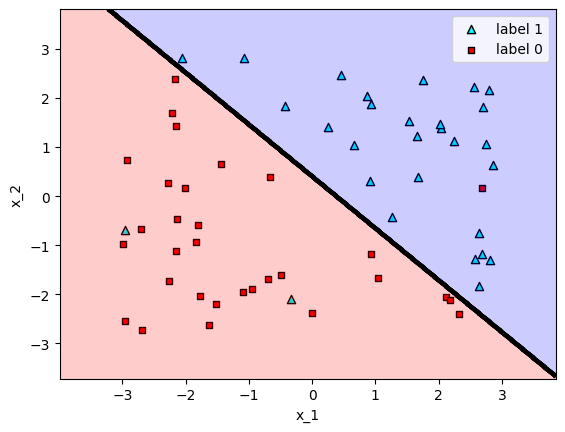

In [11]:
plot_model(features, labels, svm_linear)

## Train model with different C hyperparameter

### C hyperparameter = 0.01

In [12]:
# C = 0.01
svm_c_001 = SVC(kernel = 'linear', C = 0.01)
svm_c_001.fit(features, labels)


SVC(C=0.01, kernel='linear')

### Evaluate model -> C = 0.01

C = 0.01
Accuracy: 0.8833333333333333


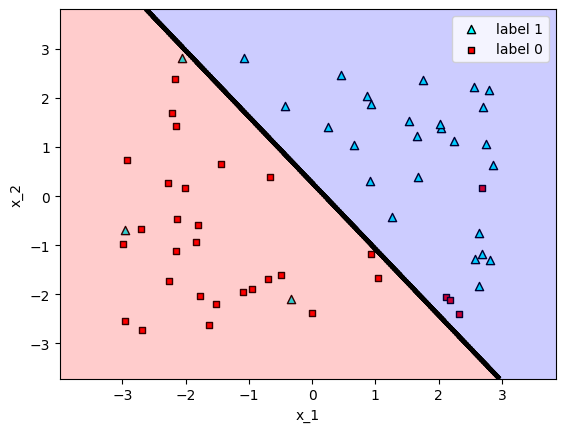

In [13]:
print("C = 0.01")
print("Accuracy:", svm_c_001.score(features, labels))
plot_model(features, labels, svm_c_001)

### C hyperparameter = 100

In [14]:
# C = 100
svm_c_100 = SVC(kernel = 'linear', C = 100)
svm_c_100.fit(features, labels)

SVC(C=100, kernel='linear')

### Evaluate model -> C = 100

C = 100
Accuracy: 0.95


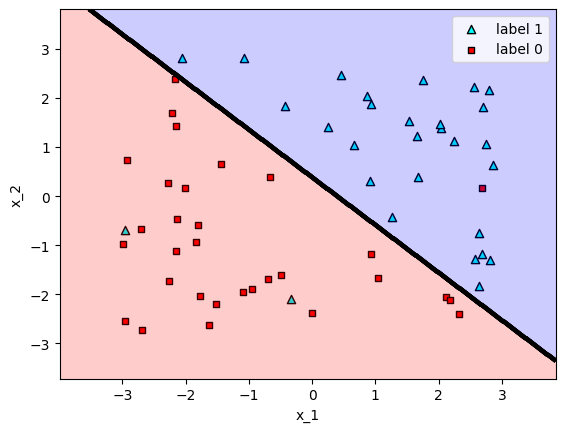

In [15]:
print("C = 100")
print("Accuracy:", svm_c_100.score(features, labels))
plot_model(features, labels, svm_c_100)

## Building polynomial kernels for a circular dataset

### Loading the one_circle dataset

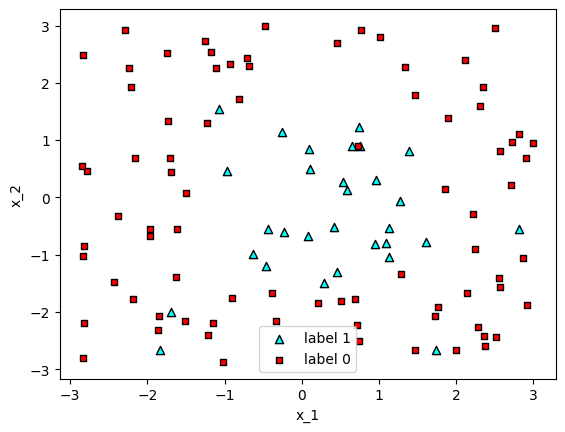

In [16]:
circular_data = pd.read_csv('one_circle.csv')
features = np.array(circular_data[['x_1', 'x_2']])
labels = np.array(circular_data['y'])
plot_points(features, labels)

### Training our SVM model with Polynomial kernel of degree = 2

Polynomial kernel of degree = 2
Accuracy: 0.9181818181818182


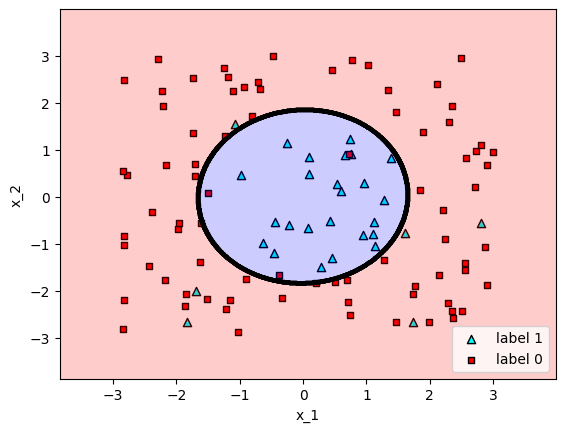

In [17]:
# Degree = 2
svm_degree_2 = SVC(kernel='poly', degree=2)
svm_degree_2.fit(features, labels)
print("Polynomial kernel of degree = 2")
print("Accuracy:", svm_degree_2.score(features, labels))
plot_model(features, labels, svm_degree_2)

## Training our SVM model with Polynomial kernel of degree = 4

Polynomial kernel of degree = 4
Accuracy: 0.8181818181818182


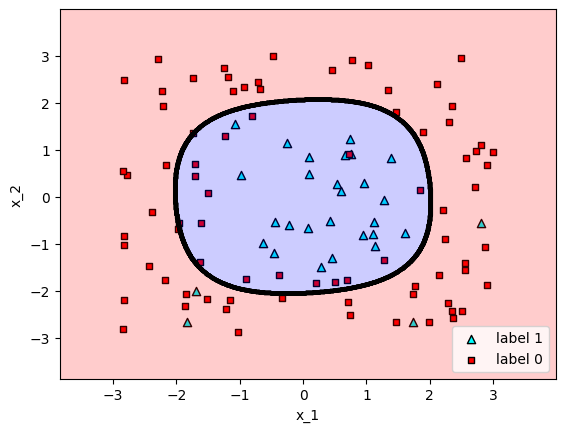

In [18]:
# Degree = 4
svm_degree_4 = SVC(kernel='poly', degree=4)
svm_degree_4.fit(features, labels)
print("Polynomial kernel of degree = 4")
print("Accuracy:", svm_degree_4.score(features, labels))
plot_model(features, labels, svm_degree_4)

## Experimenting with gammas in the rbf kernel

### Loading the two_circles dataset

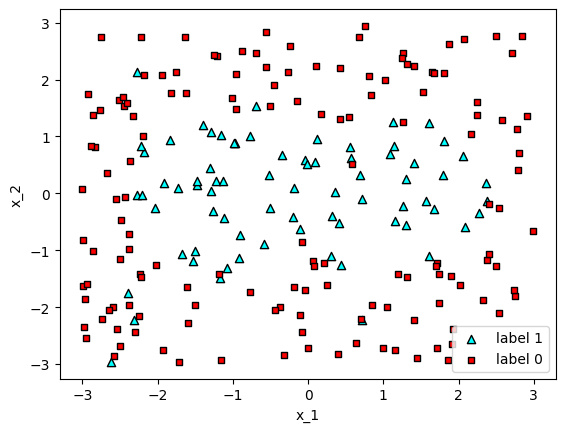

In [28]:
two_circles_data = pd.read_csv('two_circles.csv')
features = np.array(two_circles_data[['x_1', 'x_2']])
labels = np.array(two_circles_data['y'])
plot_points(features, labels)

### Training our SVM model with rbf kernel gamma = 0.1

Gamma = 0.1
Accuracy: 0.8772727272727273


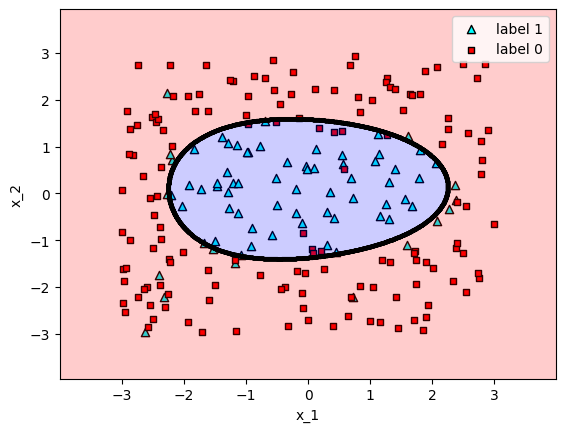

In [29]:
svm_gamma_01 = SVC(kernel='rbf', gamma=0.1)
svm_gamma_01.fit(features, labels)
print("Gamma = 0.1")
print("Accuracy:", svm_gamma_01.score(features, labels))
plot_model(features, labels, svm_gamma_01)

### Training our SVM model with rbf kernel gamma = 1

Gamma = 1
Accuracy: 0.9272727272727272


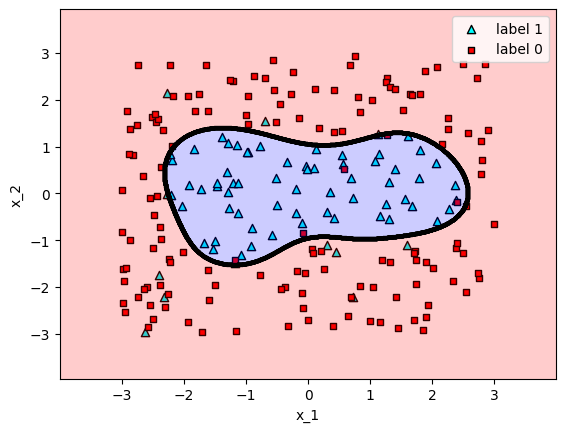

In [30]:
# gamma = 1
svm_gamma_1 = SVC(kernel='rbf', gamma=1)
svm_gamma_1.fit(features, labels)
print("Gamma = 1")
print("Accuracy:", svm_gamma_1.score(features, labels))
plot_model(features, labels, svm_gamma_1)

### Training our SVM model with rbf kernel gamma = 10

Gamma = 10
Accuracy: 0.9545454545454546


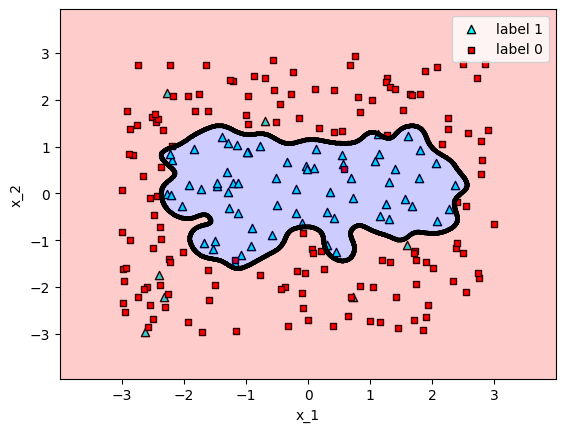

In [31]:
# gamma = 10
svm_gamma_10 = SVC(kernel='rbf', gamma=10)
svm_gamma_10.fit(features, labels)
print("Gamma = 10")
print("Accuracy:", svm_gamma_10.score(features, labels))
plot_model(features, labels, svm_gamma_10)

### Training our SVM model with rbf kernel gamma = 100

Gamma = 100
Accuracy: 0.9863636363636363


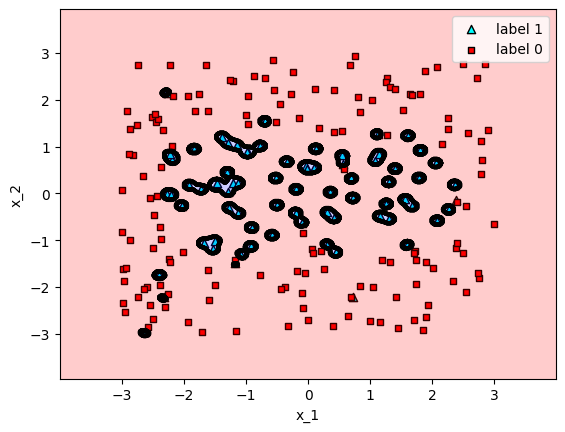

In [32]:
# gamma = 100
svm_gamma_100 = SVC(kernel='rbf', gamma=100)
svm_gamma_100.fit(features, labels)
print("Gamma = 100")
print("Accuracy:", svm_gamma_100.score(features, labels))
plot_model(features, labels, svm_gamma_100)

### With different dataset for SVM model with rbf kernel

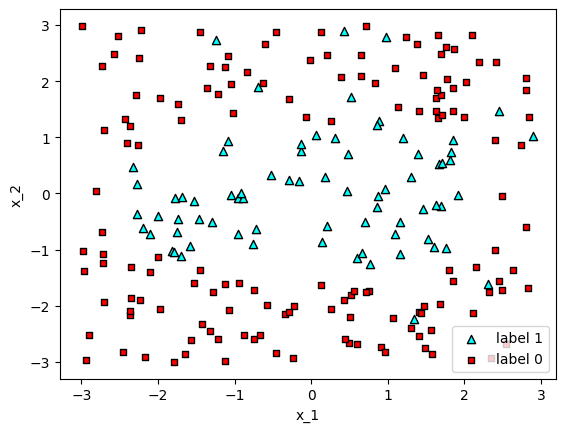

In [33]:
two_circles_data_zapata = pd.read_csv('two_circles_zapata.csv')
features = np.array(two_circles_data_zapata[['x_1', 'x_2']])
labels = np.array(two_circles_data_zapata['y'])
plot_points(features, labels)

Gamma = 0.1
Accuracy: 0.9272727272727272


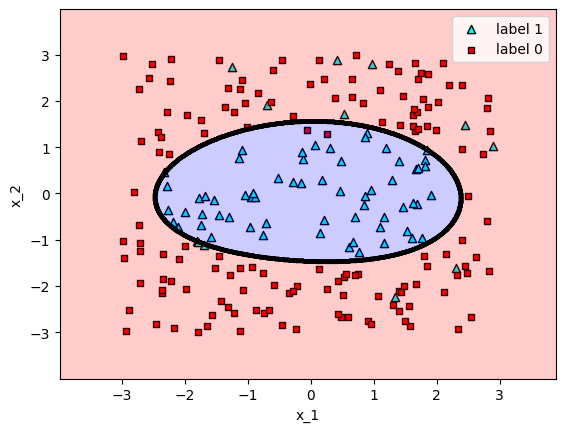

Gamma = 1
Accuracy: 0.9454545454545454


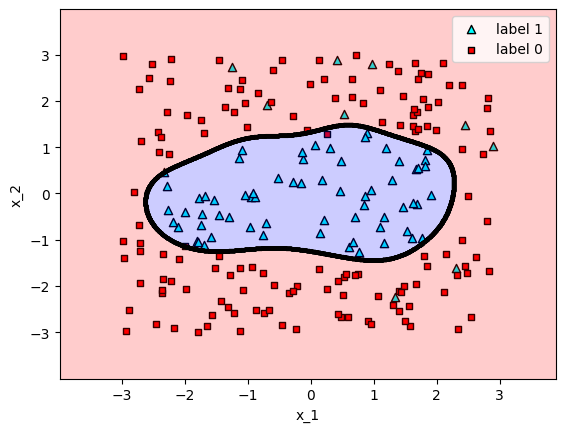

Gamma = 10
Accuracy: 0.9681818181818181


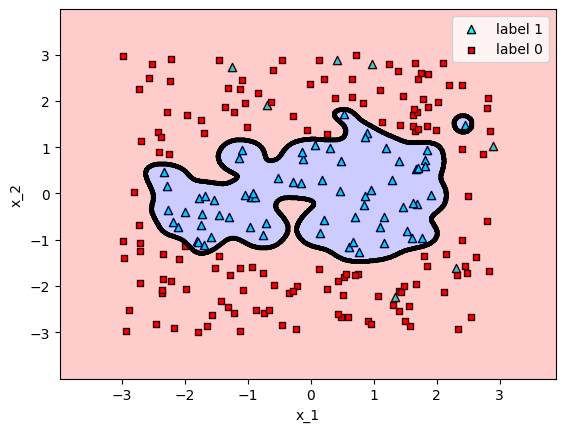

Gamma = 100
Accuracy: 1.0


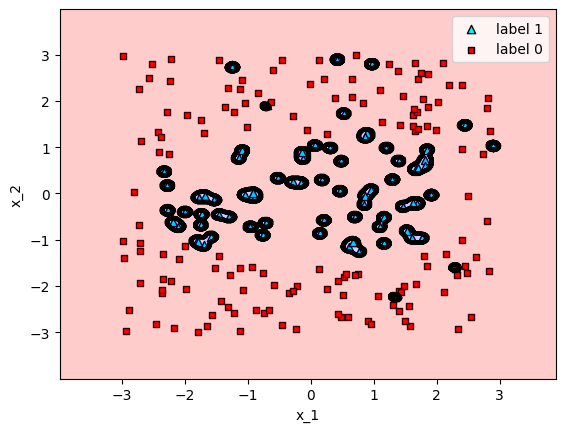

In [34]:
# gamma = 0.1
svm_gamma_01 = SVC(kernel='rbf', gamma=0.1)
svm_gamma_01.fit(features, labels)
print("Gamma = 0.1")
print("Accuracy:", svm_gamma_01.score(features, labels))
plot_model(features, labels, svm_gamma_01)

# gamma = 1
svm_gamma_1 = SVC(kernel='rbf', gamma=1)
svm_gamma_1.fit(features, labels)
print("Gamma = 1")
print("Accuracy:", svm_gamma_1.score(features, labels))
plot_model(features, labels, svm_gamma_1)

# gamma = 10
svm_gamma_10 = SVC(kernel='rbf', gamma=10)
svm_gamma_10.fit(features, labels)
print("Gamma = 10")
print("Accuracy:", svm_gamma_10.score(features, labels))
plot_model(features, labels, svm_gamma_10)

# gamma = 100
svm_gamma_100 = SVC(kernel='rbf', gamma=100)
svm_gamma_100.fit(features, labels)
print("Gamma = 100")
print("Accuracy:", svm_gamma_100.score(features, labels))
plot_model(features, labels, svm_gamma_100)